<a href="https://colab.research.google.com/github/lili-alsh/Generated_images/blob/main/%D0%9A%D0%BE%D0%BD%D1%82%D1%83%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорт библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import shuffle

import os
from tqdm import tqdm

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import imagenet_utils
# from PIL import Image

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow import keras
# from keras.metrics import mean_squared_error
from tensorflow.keras import layers as L
# from keras.models import Model
from keras.applications.resnet import ResNet50
# from keras.layers import Dense, Flatten, AveragePooling2D, Dropout
from keras.callbacks import EarlyStopping

# Константы

In [ ]:
IMG_SIZE = 224
DATA_FOLDER =  '/content/drive/MyDrive/Контур/images/'

# Обработка данных

In [ ]:
PATH_DATASET = '/content/drive/MyDrive/Контур/images/'
IMG_SIZE = 224
BATCH_SIZE = 16

In [ ]:
# Load the data
data_ds = tf.keras.utils.image_dataset_from_directory(
  PATH_DATASET + "/train",
  seed = 512,
  image_size = (IMG_SIZE, IMG_SIZE),
  batch_size = batch_size)

# Scale pixel values to the range [0, 1]
data = data.map(lambda x, y : (x/255, y))

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Контур/train.csv')

In [ ]:
test=pd.read_csv('/content/test.csv')

In [ ]:
data_image_list = os.listdir(DATA_FOLDER)
data_image = pd.DataFrame(data_image_list, columns = ['name_ext'])
data_image['name'] = data_image.name_ext.str.split('.').str.get(0)

In [ ]:
test_image = pd.DataFrame(data_image_list, columns = ['name_ext'])
test_image['name'] = test_image.name_ext.str.split('.').str.get(0)

In [ ]:
# Убираем расширения из названия файлов
data.id = data.id.str.split('.').str.get(0)
# test.id = test.id.str.split('.').str.get(0)

In [ ]:
# Объединяем данные с названием файлов и классом с путем файла
data = data.merge(data_image, how='left', left_on = 'id', right_on='name')

In [ ]:
test = test.merge(test_image, how='left', left_on = 'id', right_on='name')

In [ ]:
# Перемешиваем данные
data = shuffle(data)
data = data.reset_index()
# test = test.reset_index()

In [ ]:
# Обрабатываем картинки для подачи в нейросеть
preprocess = imagenet_utils.preprocess_input

x = []
y = []
for i, img in enumerate(data.name_ext.values):
  path = os.path.join(DATA_FOLDER,img)
  img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
  img = img_to_array(img)
  img = preprocess(img)
  x.append(img)
  y.append(data.target[i])

In [ ]:
x_test = []
for img in test.name_ext.values:
  path = os.path.join(DATA_FOLDER,img)
  img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
  img = img_to_array(img)
  img = preprocess(img)
  x_test.append(img)

In [ ]:
# Делим данные на тестовые и обучающие
x_arr = np.array(x)
y_arr = np.array(y)
# x_pred = np.array(x_test)
X_train, X_test, y_train, y_test = train_test_split(x_arr, y_arr, test_size=0.2, random_state=42)

In [ ]:
def augment_data(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    return x, y

train_augmented = data.map(augment_data)

In [ ]:
# Scale pixel values to the range [0, 1]
data = data.map(lambda x, y : (x/255, y))

# Выбор моделей

## ResNet

In [ ]:
model_resnet = Sequential()

model_resnet.add(tf.keras.applications.resnet50.ResNet50(
                                input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet'))

model_resnet.add(L.Flatten())

model_resnet.add(L.Dense(1, activation='sigmoid'))

model_resnet.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy')

In [ ]:
# for layer in model_resnet.layers[0].layers:
#     if layer.name == 'conv5_block1_0_conv':
#         break
#     layer.trainable=False
model_resnet.layers[0].trainable = False

In [ ]:
model_resnet.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 flatten_9 (Flatten)         (None, 100352)            0         
                                                                 
 dense_10 (Dense)            (None, 1)                 100353    
                                                                 
Total params: 23688065 (90.36 MB)
Trainable params: 100353 (392.00 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


In [ ]:
model_resnet.fit(X_train, y_train,
          batch_size=16, epochs=3,
          verbose=1)

Epoch 1/3
51/51 [==============================] - 544s 10s/step - loss: 0.5361
Epoch 2/3
51/51 [==============================] - 511s 10s/step - loss: 0.0196
Epoch 3/3
51/51 [==============================] - 511s 10s/step - loss: 0.0157


In [ ]:
model_resnet.evaluate(X_test, y_test)

7/7 [==============================] - 33s 4s/step - loss: 0.4428


0.4428408145904541

In [ ]:
model = Sequential()

model.add(tf.keras.applications.resnet50.ResNet50(
                                input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet'))

model.add(L.Flatten())

model.add(L.Dense(1, activation='sigmoid'))

# model.layers[0].trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy')

In [ ]:
model.summary()

In [ ]:
model.fit(X_train, y_train.reshape((-1,1)),
          batch_size=8, epochs=3,
          verbose=1)
model.evaluate(X_test, y_test.reshape((-1,1)))

In [ ]:


# Загрузка предобученной ResNet-50 модели
base_model = ResNet50(weights='imagenet',
                      include_top=False,
                      input_shape = (IMG_SIZE,IMG_SIZE,3))

# Добавление слоя для классификации
x = base_model.output
x = AveragePooling2D(pool_size=(7,7))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)

# Создание финальной модели
model = Model(inputs=base_model.input, outputs=x)

# Компиляция модели с метрикой logloss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', mean_squared_error])

# Теперь твоя модель будет использовать logloss в качестве метрики

## VGG

In [ ]:
model_vgg = Sequential()

model_vgg.add(tf.keras.applications.vgg19.VGG19(input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet'))
model_vgg.add(L.Flatten())

model_vgg.add(L.Dense(1, activation='sigmoid'))

model_vgg.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy')

NameError: name 'Sequential' is not defined

In [ ]:
model_vgg.layers[0].trainable = False

In [ ]:
model_vgg.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 flatten_10 (Flatten)        (None, 25088)             0         
                                                                 
 dense_11 (Dense)            (None, 1)                 25089     
                                                                 
Total params: 20049473 (76.48 MB)
Trainable params: 25089 (98.00 KB)
Non-trainable params: 20024384 (76.39 MB)
_________________________________________________________________


In [ ]:
model_vgg.fit(X_train, y_train,
          batch_size=16, epochs=3,
          verbose=1)
model_vgg.evaluate(X_test, y_test)

NameError: name 'model_vgg' is not defined

## Inception

In [ ]:
model_inc = Sequential()

model_inc.add(tf.keras.applications.InceptionV3(input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet'))
model_inc.add(L.Flatten())

model_inc.add(L.Dense(1, activation='sigmoid'))

model_inc.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy')

87910968/87910968 [==============================] - 4s 0us/step


In [ ]:
model_inc.layers[0].trainable = False

In [ ]:
model_inc.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 flatten (Flatten)           (None, 131072)            0         
                                                                 
 dense (Dense)               (None, 1)                 131073    
                                                                 
Total params: 21933857 (83.67 MB)
Trainable params: 131073 (512.00 KB)
Non-trainable params: 21802784 (83.17 MB)
_________________________________________________________________


In [ ]:
early_stop = EarlyStopping(monitor = 'val_loss', min_delta = 0, patience = 10,
                           verbose = 1, mode = 'max', baseline = None,
                           restore_best_weights = True)

fit_hist = model_inc.fit(X_train, y_train,
          batch_size=16, epochs=3,
          verbose=1, validation_data = (X_test, y_test), callbacks=early_stop)

Epoch 1/3
51/51 [==============================] - 845s 17s/step - loss: 0.0237 - val_loss: 0.2130
Epoch 2/3
51/51 [==============================] - 833s 16s/step - loss: 0.0078 - val_loss: 0.2050
Epoch 3/3
51/51 [==============================] - 836s 16s/step - loss: 0.0064 - val_loss: 0.2816


In [ ]:
print(fit_hist.history.keys())

dict_keys(['loss', 'val_loss'])


In [ ]:
pred = model_inc.predict(x_pred)

In [ ]:
res = pd.read_csv('/content/test.csv')
res['target'] = pred
res.to_csv('predictions.csv', index=False)

## Xception

In [ ]:
model_xc = Sequential()

model_xc.add(tf.keras.applications.Xception(input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet'))
model_xc.add(L.Flatten())

model_xc.add(L.Dense(1, activation='sigmoid'))

model_xc.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy')

83683744/83683744 [==============================] - 1s 0us/step


In [ ]:
model_xc.layers[0].trainable = False

In [ ]:
model_xc.fit(X_train, y_train,
          batch_size=16, epochs=3,
          verbose=1)
model_xc.evaluate(X_test, y_test)

## EfficientNetV2B0

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

In [ ]:
model_eff = Sequential()

model_eff.add(tf.keras.applications.EfficientNetV2B0(input_shape = (IMG_SIZE,IMG_SIZE,3),
                                include_top = False,
                                weights = 'imagenet', pooling = 'max'))
model_eff.trainable = True

inputs = tf.keras.Input(shape = (IMG_SIZE, IMG_SIZE, 3))
x = model_eff(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

EfficientNet_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_2 (Sequential)   (None, 1280)              5919312   
                                                                 
 batch_normalization_2 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_6 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 64)                16448     
                                                           

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
26/26 [==============================] - 48s 380ms/step - loss: 5.3583 - val_loss: 16.7124
Epoch 2/100
26/26 [==============================] - 5s 210ms/step - loss: 4.3506 - val_loss: 16.5359
Epoch 3/100
26/26 [==============================] - 5s 206ms/step - loss: 3.6787 - val_loss: 9.5149
Epoch 4/100
26/26 [==============================] - 5s 195ms/step - loss: 3.2292 - val_loss: 8.5570
Epoch 5/100
26/26 [==============================] - 5s 211ms/step - loss: 2.8636 - val_loss: 6.2209
Epoch 6/100
26/26 [==============================] - 5s 189ms/step - loss: 2.5558 - val_loss: 6.6005
Epoch 7/100
26/26 [==============================] - 5s 211ms/step - loss: 2.3106 - val_loss: 3.4240
Epoch 8/100
26/26 [==============================] - 5s 187ms/step - loss: 2.0545 - val_loss: 3.8420
Epoch 9/100
26/26 [==============================] - 5s 188ms/step - loss: 1.8502 - val_loss: 3.7601
Epoch 10/100
26/26 [==============================] - 5s 197ms/step - loss: 1.6599 - val

# Tourch

## Вариант 1: zero-shooting

### CLIP

In [ ]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-sm2jn7a1
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-sm2jn7a1
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_

### Creating dataset

In [ ]:
import torch
from torch import nn
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
from PIL import Image
import clip
# import os

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Setup path to data folder
image_path = Path("/content/drive/MyDrive/Контур/images/")
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('/content/drive/MyDrive/Контур/images/train'),
 PosixPath('/content/drive/MyDrive/Контур/images/test'))

In [ ]:
# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 99.1MiB/s]


In [ ]:
data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=preprocess, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

In [ ]:
validation_split =0.1
shuffle_dataset = True
random_seed= 42
workers = os.cpu_count()

In [ ]:
# Creating data indices for training and validation splits:
dataset_size = len(data)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
if shuffle_dataset :
    np.random.seed(random_seed)
    np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

# Creating PT data samplers and loaders:
train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
valid_sampler = torch.utils.data.SubsetRandomSampler(val_indices)

In [ ]:
# train_dataloader = DataLoader(dataset=train_data,
#                               batch_size=1, # how many samples per batch?
#                               num_workers=workers, # how many subprocesses to use for data loading? (higher = more)
#                               shuffle=True) # shuffle the data?

# valid_dataloader = DataLoader(dataset=valid_data,
#                              batch_size=1,
#                              num_workers=workers,
#                              shuffle=False) # don't usually need to shuffle testing data
train_loader = torch.utils.data.DataLoader(data, batch_size=1,
                                           sampler=train_sampler)
validation_loader = torch.utils.data.DataLoader(data, batch_size=1,
                                                sampler=valid_sampler)

### Calculate the image features

In [ ]:
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in data.classes]).to(device)

In [ ]:
def get_features(image):
    # all_features = []
    # all_labels = []

    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        image_features = model.encode_image(image.to(device))
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        top_probs, top_labels = text_probs.cpu().topk(2, dim=-1)
            # all_features.append(features)
            # all_labels.append(labels)

    return top_probs, top_labels
    #torch.cat(all_features).cpu().numpy(), text_features #torch.cat(all_labels).cpu().numpy()

In [ ]:
all_probs = []
all_labels = []

for images, labels in train_loader:
    a = get_features(images)
    all_probs.append(a[0].numpy())
    all_labels.append(a[1].numpy())

In [ ]:
all_labels = np.array(all_labels).reshape(911,2)

In [ ]:
all_probs = np.array(all_probs).reshape(911,2)

In [ ]:
from sklearn.metrics import log_loss
log_loss(all_labels, all_probs)

0.8203131869630612

In [ ]:
all_probs = []
all_labels = []

for images, labels in validation_loader:
    a = get_features(images)
    all_probs.append(a[0].numpy())
    all_labels.append(a[1].numpy())

In [ ]:
log_loss(np.array(all_labels).reshape(101,2), np.array(all_probs).reshape(101,2))

0.8202191037005326

In [ ]:
img_train_features, txt_train_features = get_features(train_loader)
img_val_features, txt_val_features = get_features(validation_loader)

In [ ]:
n = len(data)  # total number of examples
n_test = int(0.2 * n)  # take ~10% for test

valid_data = torch.utils.data.Subset(data, range(n_test))  # take first 10%
train_data = torch.utils.data.Subset(data, range(n_test, n))  # take the rest

print(f"Train data:\nNumber of datapoints:{len(train_data)}\nValid data:\nNumber of datapoints:{len(valid_data)}")

In [ ]:
train_loader = torch.utils.data.DataLoader(data, batch_size=1,
                                           sampler=train_sampler)
validation_loader = torch.utils.data.DataLoader(data, batch_size=1,
                                                sampler=valid_sampler)

## Вариант 2: CLIP +

### CLIP

In [1]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-yqdai3rv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-yqdai3rv
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_

### Импорт библиотек

In [68]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets
import numpy as np
from tqdm import tqdm
import clip
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 49.0MiB/s]


### Импорт данных

In [5]:
# Setup path to data folder
image_path = Path("/content/drive/MyDrive/Контур/images/")
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=preprocess, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

### Calculate the image features

In [7]:
def get_features(dataset):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(DataLoader(dataset, batch_size=100)):
            features = model.encode_image(images.to(device))

            all_features.append(features)
            all_labels.append(labels)

    return torch.cat(all_features).cpu().numpy(), torch.cat(all_labels).cpu().numpy()

In [8]:
# Calculate the image features
features, labels = get_features(data)
# test_features, test_labels = get_features(test)

100%|██████████| 11/11 [05:53<00:00, 32.09s/it]


### Разделение на тест и трейн

In [9]:
from sklearn.model_selection import train_test_split

In [113]:
train_embeddings, val_embeddings, train_labels, val_labels = train_test_split(
    features, labels, test_size=0.33, random_state=42)

### Понижение размерности

#### PCA

In [11]:
from sklearn.decomposition import PCA

In [ ]:
# import seaborn as sns; sns.set()

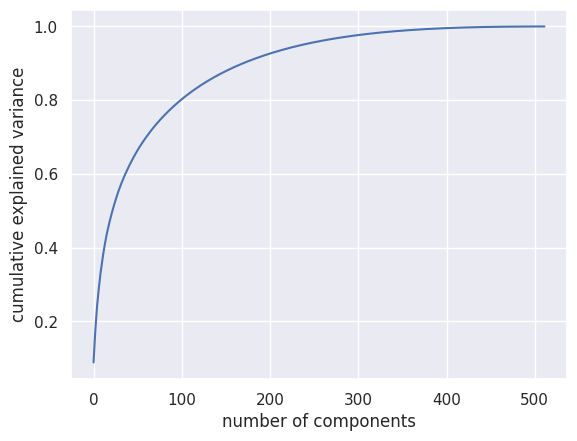

In [ ]:
pca = PCA().fit(features)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [12]:
pca = PCA(200)

In [13]:
train_embeddings_pca = pca.fit_transform(train_embeddings)
val_embeddings_pca = pca.transform(val_embeddings)

#### TSNE

In [14]:
from sklearn.manifold import TSNE

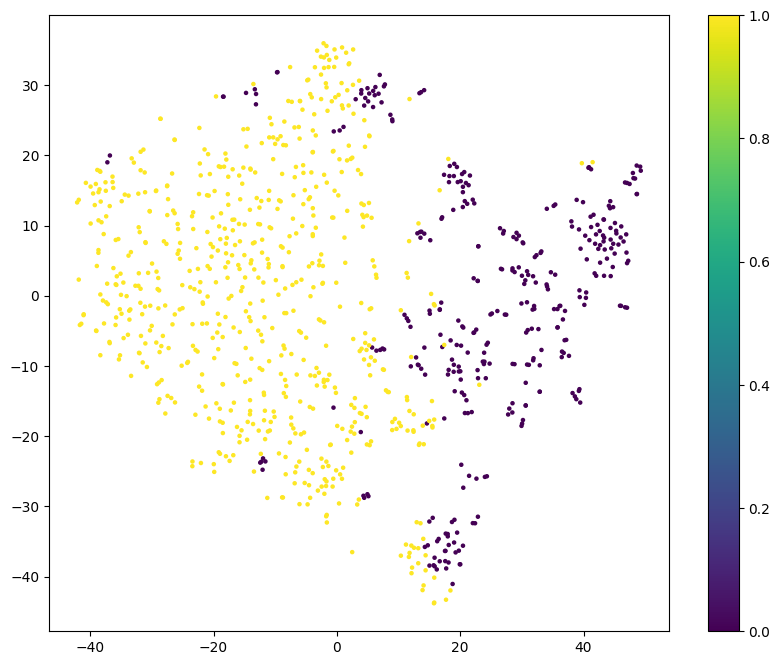

In [15]:
tsne_transformed = TSNE(learning_rate='auto').fit_transform(features)
plt.figure(figsize=(10, 8))
plt.scatter(tsne_transformed[:, 0], tsne_transformed[:, 1], s=5, c=labels)
plt.colorbar();

#### UMAP

In [17]:
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.7 MB/s eta 0:00:00


In [18]:
from umap import UMAP

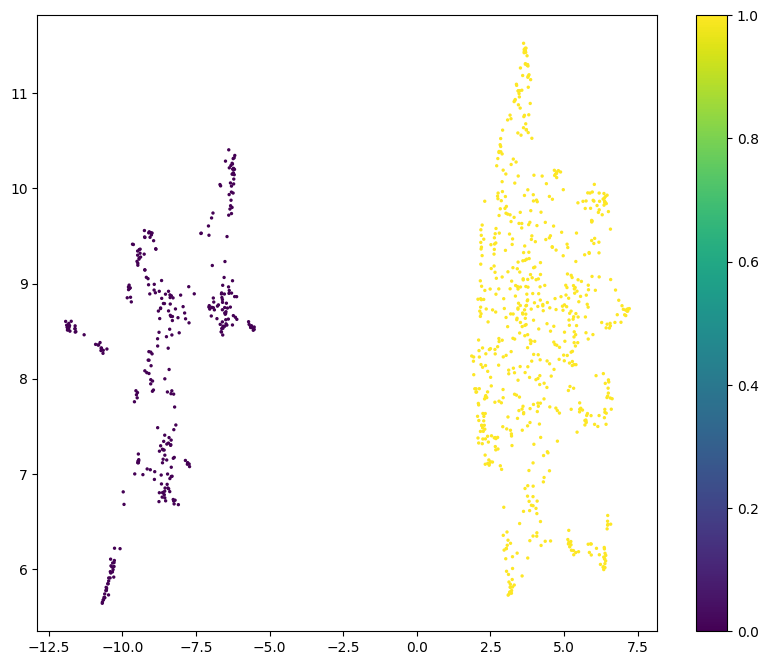

In [21]:
umap_transformed = UMAP().fit_transform(features, labels)
plt.figure(figsize=(10, 8))
plt.scatter(umap_transformed[:, 0], umap_transformed[:, 1], s=2, c=labels)
plt.colorbar();

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


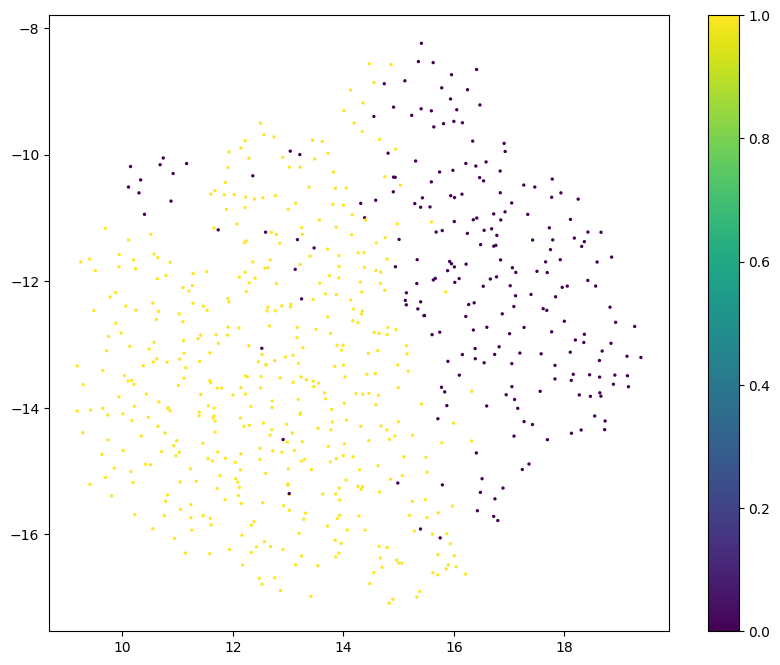

In [63]:
train_clusterable_embedding = UMAP(n_neighbors=200, min_dist=0.99,
                                   n_components=2, random_state=42).fit_transform(train_embeddings)
plt.figure(figsize=(10, 8))
plt.scatter(train_clusterable_embedding[:, 0], train_clusterable_embedding[:, 1],
            s=2, c=train_labels)
plt.colorbar();

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


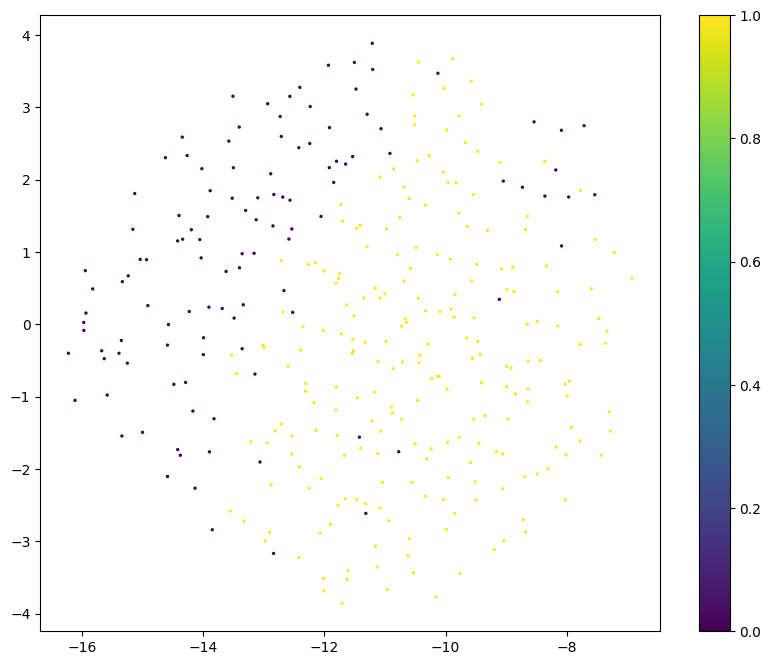

In [60]:
val_clusterable_embedding = UMAP(n_neighbors=200, min_dist=0.99,
                                   n_components=2, random_state=42).fit_transform(val_embeddings)
plt.figure(figsize=(10, 8))
plt.scatter(val_clusterable_embedding[:, 0], val_clusterable_embedding[:, 1],
            s=2, c=val_labels)
plt.colorbar();

##### Подбор параметров

In [41]:
def draw_umap(n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    u = fit.fit_transform(train_embeddings);
    fig = plt.figure()
    if n_components == 1:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], range(len(u)), c=train_labels)
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], u[:,1], c=train_labels)
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(u[:,0], u[:,1], u[:,2], c=train_labels, s=100)
    plt.title(title, fontsize=18)

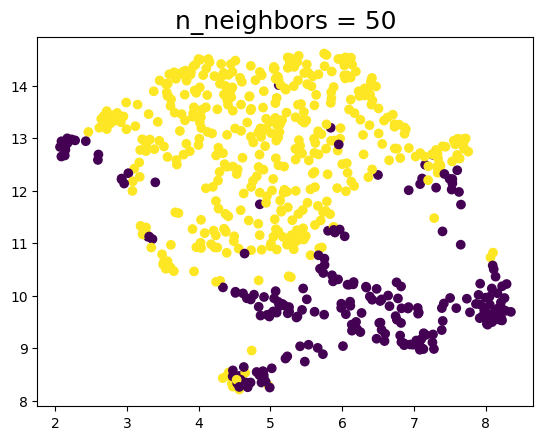

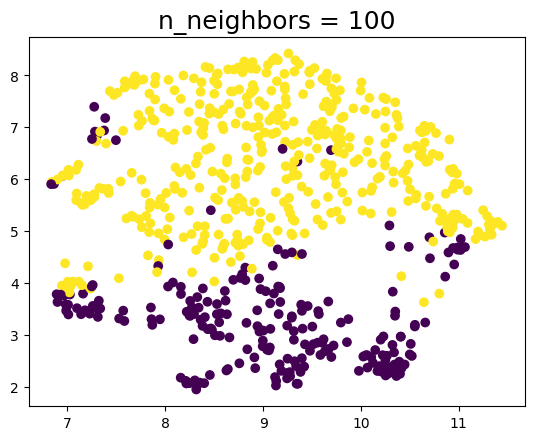

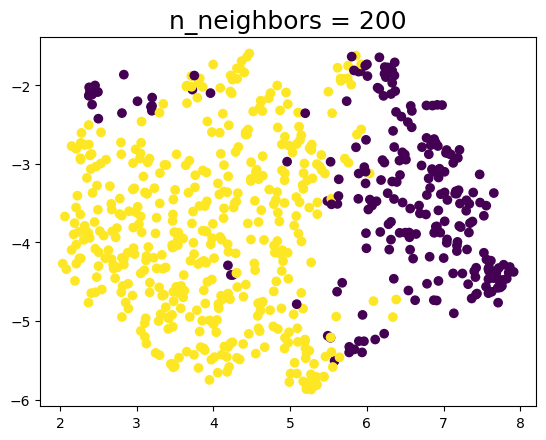

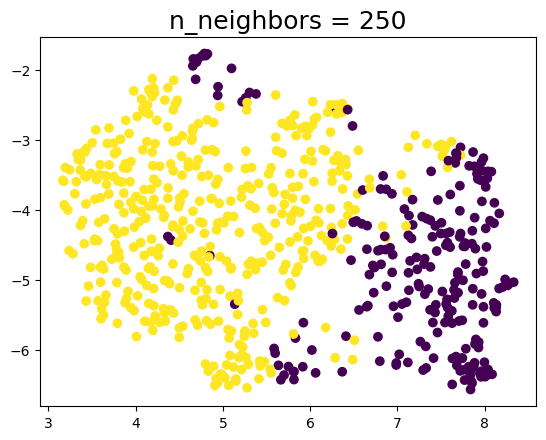

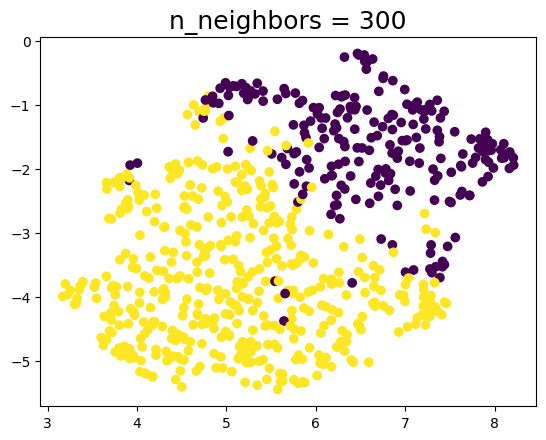

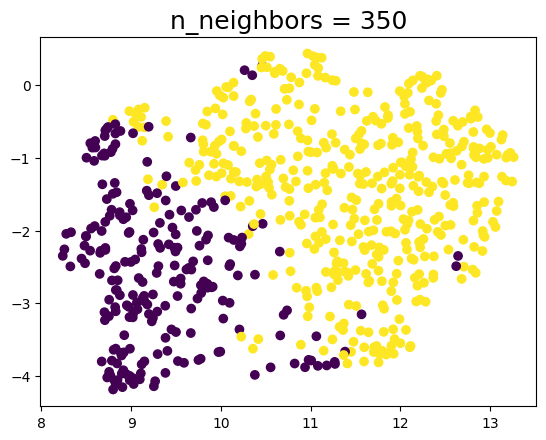

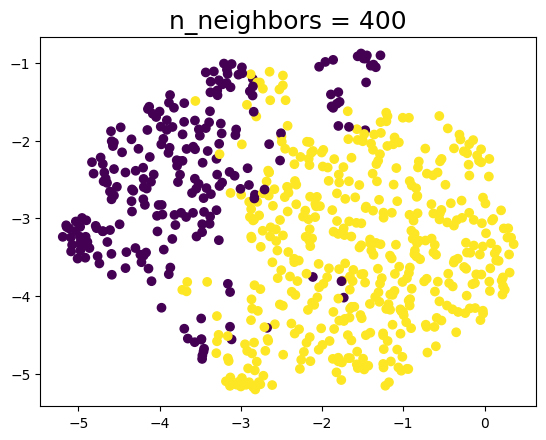

In [38]:
for n in (50, 100, 200, 250, 300, 350, 400):
    draw_umap(n_neighbors=n, title='n_neighbors = {}'.format(n))

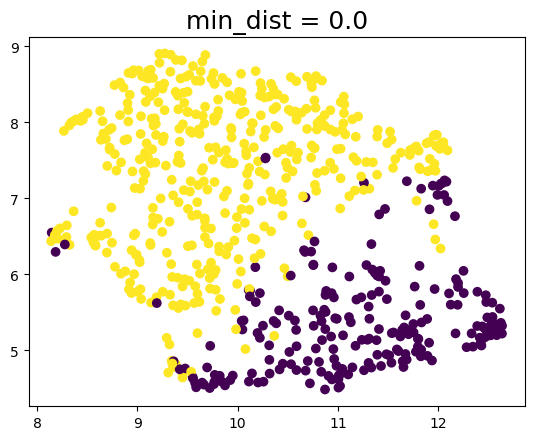

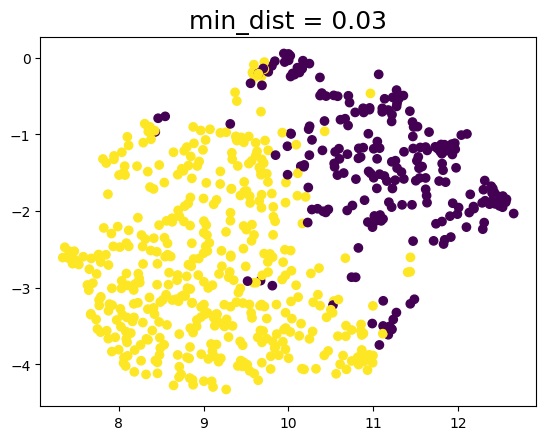

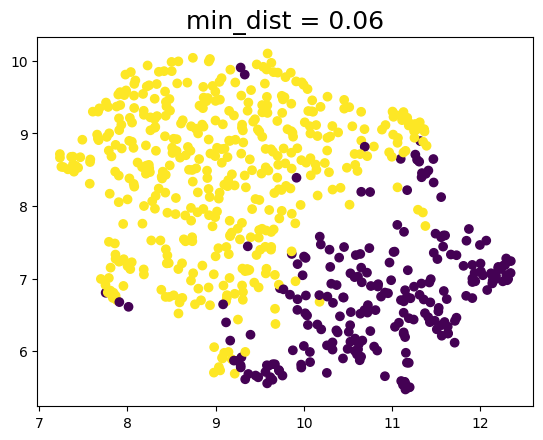

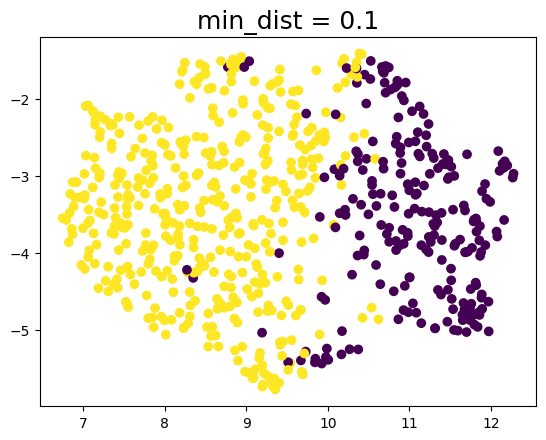

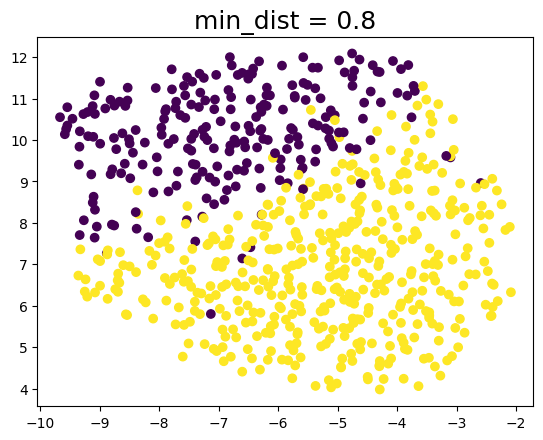

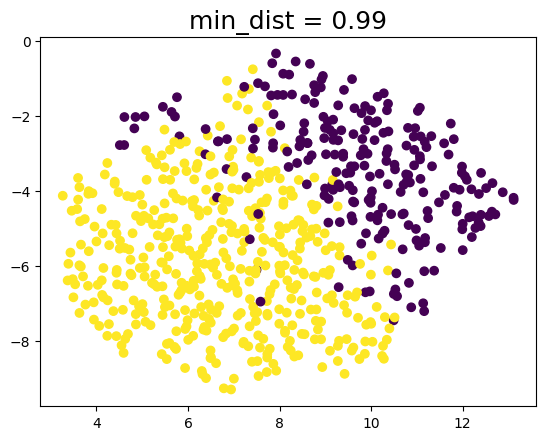

In [45]:
for d in (0.0, 0.03, 0.06, 0.1, 0.8, 0.99):
    draw_umap(min_dist=d, title='min_dist = {}'.format(d))

### Предсказание

#### xgboost

In [65]:
! pip install xgboost

In [66]:
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [71]:
params = { 'max_depth': [3,6],
           'n_estimators': [100, 200, 300]}
xgbr = xgb.XGBClassifier(seed = 20)
clf = GridSearchCV(estimator=xgbr,
                   param_grid=params,
                   scoring=log_loss,
                   verbose=1,
                   n_jobs=-1)
clf.fit(train_embeddings_pca, train_labels)
print("Best parameters:", clf.best_params_)
print("Best accuracy: ", clf.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


Best parameters: {'max_depth': 3, 'n_estimators': 100}
Best accuracy:  nan


In [78]:
xgbr = xgb.XGBClassifier(max_depth = 3, n_estimators=100, seed = 20)
xgbr.fit(train_embeddings_pca, train_labels)
predict = xgbr.predict_proba(val_embeddings_pca)
log_loss(val_labels, predict)

0.2222435187349481

#### KNeighborsClassifier

In [84]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [86]:
for k_i in range(1, 10):
  neigh = KNeighborsClassifier(k_i)
  neigh.fit(train_embeddings_pca, train_labels)
  predict = neigh.predict_proba(val_embeddings_pca)
  print(log_loss(val_labels, predict))

1.6187269486130458
0.7242765449563501
0.7417464480979841
0.440857327102288
0.3433612747304746
0.24874641356203547
0.25065264492077327
0.14840966783836057
0.1512957506355421


In [87]:
for k_i in range(1, 10):
  neigh = KNeighborsClassifier(k_i)
  neigh.fit(train_clusterable_embedding, train_labels)
  predict = neigh.predict_proba(val_clusterable_embedding)
  print(log_loss(val_labels, predict))

14.460627407609877
6.825631966651676
5.172158759046936
1.5824108871153424
0.6658264857455856
0.6574241340227045
0.6715796040481087
0.6874956466571127
0.6854283119891863


#### HDBSCAN

In [91]:
!pip install hdbscan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 19.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached Cython-0.29.37-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_24_x86_64.whl (1.9 MB)
  Created wheel for hdbscan: filename=hdbscan-0.8.33-cp310-cp310-linux_x86_64.whl size=3039292 sha256=afd83feec7e1dab595540182c4e6564d08e306874d02c602c0be7e3cb8e8c282
  Stored in directory: /root/.cache/pip/wheels/75/0b/3b/dc4f60b7cc455efaefb62883a7483e76f09d06ca81cf87d610
Successfully built hdbscan
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.10
    Uninstalling Cython-3.0.10:
      Successfully uninstalled Cython-3.0.10


In [92]:
import hdbscan

In [114]:
cluster_model = hdbscan.HDBSCAN(
  #  min_cluster_size=30,
  #  alpha=2.,
  #  cluster_selection_method="leaf",
   prediction_data=True
)
cluster_model.fit_predict(train_clusterable_embedding)

train_labels_, train_probabilities = hdbscan.approximate_predict(cluster_model,
                                                                train_clusterable_embedding)
log_loss(train_labels, train_probabilities)
# test_labels, test_probabilities = hdbscan.approximate_predict(cluster_model, val_clusterable_embeddings)

15.262435756701183

In [110]:
train_probabilities.shape

(678,)

## Loading test

In [ ]:
test = datasets.ImageFolder(root=test_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None)

In [ ]:
test_dataloader = DataLoader(dataset=test,
                             batch_size=1,
                             num_workers=2,
                             shuffle=False) # don't usually need to shuffle testing data

## Text

In [ ]:
! pip install ftfy regex
! wget https://openaipublic.azureedge.net/clip/bpe_simple_vocab_16e6.txt.gz -O bpe_simple_vocab_16e6.txt.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.8 MB/s eta 0:00:00
--2024-05-04 11:13:17--  https://openaipublic.azureedge.net/clip/bpe_simple_vocab_16e6.txt.gz
Resolving openaipublic.azureedge.net (openaipublic.azureedge.net)... 13.107.246.67, 13.107.213.67, 2620:1ec:bdf::67, ...
Connecting to openaipublic.azureedge.net (openaipublic.azureedge.net)|13.107.246.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1356917 (1.3M) [application/octet-stream]
Saving to: ‘bpe_simple_vocab_16e6.txt.gz’

bpe_simple_vocab_16 100%[===================>]   1.29M  3.53MB/s    in 0.4s    

2024-05-04 11:13:19 (3.53 MB/s) - ‘bpe_simple_vocab_16e6.txt.gz’ saved [1356917/1356917]



In [ ]:
#@title

import gzip
import html
import os
from functools import lru_cache

import ftfy
import regex as re


@lru_cache()
def bytes_to_unicode():
    """
    Returns list of utf-8 byte and a corresponding list of unicode strings.
    The reversible bpe codes work on unicode strings.
    This means you need a large # of unicode characters in your vocab if you want to avoid UNKs.
    When you're at something like a 10B token dataset you end up needing around 5K for decent coverage.
    This is a signficant percentage of your normal, say, 32K bpe vocab.
    To avoid that, we want lookup tables between utf-8 bytes and unicode strings.
    And avoids mapping to whitespace/control characters the bpe code barfs on.
    """
    bs = list(range(ord("!"), ord("~")+1))+list(range(ord("¡"), ord("¬")+1))+list(range(ord("®"), ord("ÿ")+1))
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8+n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(bs, cs))


def get_pairs(word):
    """Return set of symbol pairs in a word.
    Word is represented as tuple of symbols (symbols being variable-length strings).
    """
    pairs = set()
    prev_char = word[0]
    for char in word[1:]:
        pairs.add((prev_char, char))
        prev_char = char
    return pairs


def basic_clean(text):
    text = ftfy.fix_text(text)
    text = html.unescape(html.unescape(text))
    return text.strip()


def whitespace_clean(text):
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text


class SimpleTokenizer(object):
    def __init__(self, bpe_path: str = "bpe_simple_vocab_16e6.txt.gz"):
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        merges = gzip.open(bpe_path).read().decode("utf-8").split('\n')
        merges = merges[1:49152-256-2+1]
        merges = [tuple(merge.split()) for merge in merges]
        vocab = list(bytes_to_unicode().values())
        vocab = vocab + [v+'</w>' for v in vocab]
        for merge in merges:
            vocab.append(''.join(merge))
        vocab.extend(['<|startoftext|>', '<|endoftext|>'])
        self.encoder = dict(zip(vocab, range(len(vocab))))
        self.decoder = {v: k for k, v in self.encoder.items()}
        self.bpe_ranks = dict(zip(merges, range(len(merges))))
        self.cache = {'<|startoftext|>': '<|startoftext|>', '<|endoftext|>': '<|endoftext|>'}
        self.pat = re.compile(r"""<\|startoftext\|>|<\|endoftext\|>|'s|'t|'re|'ve|'m|'ll|'d|[\p{L}]+|[\p{N}]|[^\s\p{L}\p{N}]+""", re.IGNORECASE)

    def bpe(self, token):
        if token in self.cache:
            return self.cache[token]
        word = tuple(token[:-1]) + ( token[-1] + '</w>',)
        pairs = get_pairs(word)

        if not pairs:
            return token+'</w>'

        while True:
            bigram = min(pairs, key = lambda pair: self.bpe_ranks.get(pair, float('inf')))
            if bigram not in self.bpe_ranks:
                break
            first, second = bigram
            new_word = []
            i = 0
            while i < len(word):
                try:
                    j = word.index(first, i)
                    new_word.extend(word[i:j])
                    i = j
                except:
                    new_word.extend(word[i:])
                    break

                if word[i] == first and i < len(word)-1 and word[i+1] == second:
                    new_word.append(first+second)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_word = tuple(new_word)
            word = new_word
            if len(word) == 1:
                break
            else:
                pairs = get_pairs(word)
        word = ' '.join(word)
        self.cache[token] = word
        return word

    def encode(self, text):
        bpe_tokens = []
        text = whitespace_clean(basic_clean(text)).lower()
        for token in re.findall(self.pat, text):
            token = ''.join(self.byte_encoder[b] for b in token.encode('utf-8'))
            bpe_tokens.extend(self.encoder[bpe_token] for bpe_token in self.bpe(token).split(' '))
        return bpe_tokens

    def decode(self, tokens):
        text = ''.join([self.decoder[token] for token in tokens])
        text = bytearray([self.byte_decoder[c] for c in text]).decode('utf-8', errors="replace").replace('</w>', ' ')
        return text


In [ ]:
MODELS = {
    "ViT-B/32":       "https://openaipublic.azureedge.net/clip/models/40d365715913c9da98579312b702a82c18be219cc2a73407c4526f58eba950af/ViT-B-32.pt",
}

In [ ]:
! wget {MODELS["ViT-B/32"]} -O model.pt

--2024-05-04 11:07:44--  https://openaipublic.azureedge.net/clip/models/40d365715913c9da98579312b702a82c18be219cc2a73407c4526f58eba950af/ViT-B-32.pt
Resolving openaipublic.azureedge.net (openaipublic.azureedge.net)... 13.107.246.67, 13.107.213.67, 2620:1ec:bdf::67, ...
Connecting to openaipublic.azureedge.net (openaipublic.azureedge.net)|13.107.246.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353976522 (338M) [application/octet-stream]
Saving to: ‘model.pt’

model.pt            100%[===================>] 337.58M  97.1MB/s    in 3.4s    

2024-05-04 11:07:47 (98.2 MB/s) - ‘model.pt’ saved [353976522/353976522]



In [ ]:
model = torch.jit.load("model.pt").cuda().eval()
input_resolution = model.input_resolution.item()
context_length = model.context_length.item()
vocab_size = model.vocab_size.item()

In [ ]:
def get_features(dataloader):
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            features = model.encode_image(images.to(device))

            all_features.append(features)
            all_labels.append(labels)

    return torch.cat(all_features).cpu().numpy(), torch.cat(all_labels).cpu().numpy()

In [ ]:
train_features, train_labels = get_features(train_loader)

100%|██████████| 911/911 [04:25<00:00,  3.43it/s]


NameError: name 'valid_loader' is not defined

In [ ]:
valid_features, valid_labels = get_features(validation_loader)

100%|██████████| 101/101 [00:28<00:00,  3.54it/s]


In [ ]:
valid_labels

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1])

In [ ]:
train_labels

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,

In [ ]:
# Perform logistic regression
classifier = LogisticRegression(random_state=0, C=2.451, max_iter=80, verbose=1)
# classifier = LogisticRegression()
classifier.fit(train_features, train_labels)

# Evaluate using the logistic regression classifier
predictions = classifier.predict_proba(valid_features)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
log_loss(valid_labels, predictions)

0.05930454459177419

In [ ]:
def evaluate(X_tr, Y_tr, X_val, Y_val, params):
    model = LogisticRegression()
    # Мы должны использовать set_params для передачи параметров объекту модели.
    # Это имеет преимущество перед использованием setattr в том, что он позволяет Scikit научиться выполнять некоторые проверки правильности параметров.
    model.set_params(**params)

    model.fit(X_tr,Y_tr)

    Y_pred = model.predict_proba(X_val)
    logg_loss = log_loss(Y_val,Y_pred)
    return logg_loss

In [ ]:
C=0.001
iterations = 500
results = np.zeros((iterations, 2))

for i in range(0,iterations):
    model_params = {'C':C,'random_state':1}
    score = evaluate(train_features, train_labels, valid_features, valid_labels, model_params)
    results[i] = C, score
    C+=0.005


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
res_df = pd.DataFrame(  data=results[0:,0:],
                        columns=['C','Log-loss'])
res_df.sort_values(by='Log-loss').head(1)

,C,Log-loss
490,2.451,0.059921


In [ ]:
max_iter=5
iterations = 40
results = np.zeros((iterations, 2))

for i in range(0,iterations):
    model_params = {'C':2.451,'random_state':1, 'max_iter':max_iter}
    score = evaluate(train_features, train_labels, valid_features, valid_labels, model_params)
    results[i] = max_iter, score
    max_iter += 5

res_df = pd.DataFrame(  data=results[0:,0:],
                        columns=['max_iter','Log-loss'])
res_df.sort_values(by='Log-loss').head(1)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,max_iter,Log-loss
15,80.0,0.059305


In [ ]:
from sklearn.svm import SVC
polysvc = SVC(kernel = 'rbf', probability = True)
polysvc.fit(train_features, train_labels)
predictions = polysvc.predict_proba(valid_features)

In [ ]:
log_loss(valid_labels, predictions)

0.11781512698748828

In [ ]:
! pip install xgboost

In [ ]:
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
params = { 'max_depth': [3,6],
           'n_estimators': [100, 200, 300]}
xgbr = xgb.XGBClassifier(seed = 20)
clf = GridSearchCV(estimator=xgbr,
                   param_grid=params,
                   scoring=log_loss,
                   verbose=1,
                   n_jobs=-1)
clf.fit(train_features, train_labels)
print("Best parameters:", clf.best_params_)
print("Best accuracy: ", clf.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


Best parameters: {'max_depth': 3, 'n_estimators': 100}
Best accuracy:  nan


In [ ]:
xgbr = xgb.XGBClassifier(seed = 20, max_depth=3, n_estimators=100)
xgbr.fit(train_features, train_labels)
predictions = xgbr.predict_proba(valid_features)
log_loss(valid_labels, predictions)

0.26347610790272613

In [ ]:
! pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 4.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
catboost = CatBoostClassifier()
catboost.fit(train_features, train_labels)
predictions = catboost.predict_proba(valid_features)
log_loss(valid_labels, predictions)

Learning rate set to 0.0099
0:	learn: 0.6864953	total: 486ms	remaining: 8m 5s
1:	learn: 0.6805092	total: 765ms	remaining: 6m 21s
2:	learn: 0.6745635	total: 988ms	remaining: 5m 28s
3:	learn: 0.6672573	total: 1.16s	remaining: 4m 49s
4:	learn: 0.6608817	total: 1.37s	remaining: 4m 32s
5:	learn: 0.6537562	total: 1.61s	remaining: 4m 26s
6:	learn: 0.6471635	total: 1.83s	remaining: 4m 19s
7:	learn: 0.6410630	total: 2.08s	remaining: 4m 18s
8:	learn: 0.6351743	total: 2.36s	remaining: 4m 20s
9:	learn: 0.6292052	total: 2.6s	remaining: 4m 17s
10:	learn: 0.6228456	total: 2.89s	remaining: 4m 19s
11:	learn: 0.6163093	total: 3.13s	remaining: 4m 18s
12:	learn: 0.6107210	total: 3.42s	remaining: 4m 20s
13:	learn: 0.6057830	total: 3.71s	remaining: 4m 20s
14:	learn: 0.6012155	total: 3.94s	remaining: 4m 18s
15:	learn: 0.5952226	total: 4.15s	remaining: 4m 15s
16:	learn: 0.5900312	total: 4.39s	remaining: 4m 13s
17:	learn: 0.5843895	total: 4.66s	remaining: 4m 14s
18:	learn: 0.5800272	total: 4.94s	remaining: 4m 

0.20926198174593147

# CIFAKE

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

NameError: name 'tf' is not defined

# Fine-tuning CNN

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
# from IPython.display import Image

## Feature engineering

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Контур/images/train/",
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(224, 224),
  batch_size=8)

val_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Контур/images/train/",
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(224, 224),
  batch_size=8)

Found 1012 files belonging to 2 classes.
Using 810 files for training.
Found 1012 files belonging to 2 classes.
Using 202 files for validation.


In [ ]:
# Scale pixel values to the range [0, 1]
train_ds = train_ds.map(lambda x, y : (x/255, y))
val_ds = val_ds.map(lambda x, y : (x/255, y))

In [ ]:
# Data Augmentation in the pipeline
def augment_data(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    return x, y

In [ ]:
train_ds = train_ds.map(augment_data)
val_ds = val_ds.map(augment_data)

## Model's choice

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .0001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization_4 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_12 (Dense)            (None, 256)               327936    
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 64)                1644

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  patience = 10,
                                                  restore_best_weights = True,
                                                  min_delta=0.01)

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 57s 253ms/step - loss: 6.3084 - val_loss: 6.9938
Epoch 2/100
51/51 [==============================] - 12s 204ms/step - loss: 5.9270 - val_loss: 6.3119
Epoch 3/100
51/51 [==============================] - 13s 239ms/step - loss: 5.7389 - val_loss: 5.9968
Epoch 4/100
51/51 [==============================] - 12s 218ms/step - loss: 5.5935 - val_loss: 5.8275
Epoch 5/100
51/51 [==============================] - 12s 215ms/step - loss: 5.4863 - val_loss: 5.6769
Epoch 6/100
51/51 [==============================] - 12s 222ms/step - loss: 5.3544 - val_loss: 5.5586
Epoch 7/100
51/51 [==============================] - 12s 223ms/step - loss: 5.2627 - val_loss: 5.4567
Epoch 8/100
51/51 [==============================] - 12s 217ms/step - loss: 5.1786 - val_loss: 5.3935
Epoch 9/100
51/51 [==============================] - 12s 218ms/step - loss: 5.0758 - val_loss: 5.2617
Epoch 10/100
51/51 [==============================] - 12s 219ms/step - loss: 4.967

In [ ]:
EfficientNet_model.evaluate(val_ds)

13/13 [==============================] - 2s 106ms/step - loss: 0.5718


0.5717586278915405

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .6, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

24274472/24274472 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                              

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 195s 3s/step - loss: 5.4397 - val_loss: 10.9317
Epoch 2/100
51/51 [==============================] - 11s 202ms/step - loss: 4.5216 - val_loss: 7.5021
Epoch 3/100
51/51 [==============================] - 11s 206ms/step - loss: 4.1298 - val_loss: 4.6673
Epoch 4/100
51/51 [==============================] - 11s 193ms/step - loss: 3.5772 - val_loss: 5.4365
Epoch 5/100
51/51 [==============================] - 10s 181ms/step - loss: 3.1827 - val_loss: 4.0506
Epoch 6/100
51/51 [==============================] - 10s 175ms/step - loss: 2.8777 - val_loss: 2.9331
Epoch 7/100
51/51 [==============================] - 11s 205ms/step - loss: 2.5719 - val_loss: 2.7286
Epoch 8/100
51/51 [==============================] - 11s 195ms/step - loss: 2.3144 - val_loss: 2.5128
Epoch 9/100
51/51 [==============================] - 10s 172ms/step - loss: 2.1251 - val_loss: 2.4262
Epoch 10/100
51/51 [==============================] - 11s 191ms/step - loss: 1.9073

In [ ]:
EfficientNet_model.evaluate(val_ds)

13/13 [==============================] - 2s 63ms/step - loss: 0.0810


0.08104889839887619

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (128, 128, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (128, 128, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization_3 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_9 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_10 (Dense)            (None, 64)                1644

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 51s 242ms/step - loss: 5.0814 - val_loss: 8.0636
Epoch 2/100
51/51 [==============================] - 9s 155ms/step - loss: 3.8829 - val_loss: 5.8877
Epoch 3/100
51/51 [==============================] - 10s 185ms/step - loss: 3.1411 - val_loss: 4.3668
Epoch 4/100
51/51 [==============================] - 11s 206ms/step - loss: 2.5929 - val_loss: 4.3445
Epoch 5/100
51/51 [==============================] - 10s 178ms/step - loss: 2.2282 - val_loss: 2.2893
Epoch 6/100
51/51 [==============================] - 9s 155ms/step - loss: 1.8709 - val_loss: 2.0597
Epoch 7/100
51/51 [==============================] - 10s 166ms/step - loss: 1.5791 - val_loss: 1.6363
Epoch 8/100
51/51 [==============================] - 10s 184ms/step - loss: 1.3390 - val_loss: 1.3897
Epoch 9/100
51/51 [==============================] - 9s 170ms/step - loss: 1.1385 - val_loss: 1.1831
Epoch 10/100
51/51 [==============================] - 8s 150ms/step - loss: 1.0055 - 

In [ ]:
EfficientNet_model.evaluate(val_ds)

13/13 [==============================] - 1s 48ms/step - loss: 0.1866


0.18660420179367065

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization_4 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_12 (Dense)            (None, 256)               327936    
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 64)                1644

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
26/26 [==============================] - 57s 421ms/step - loss: 5.2526 - val_loss: 7.1743
Epoch 2/100
26/26 [==============================] - 11s 353ms/step - loss: 4.1688 - val_loss: 4.3072
Epoch 3/100
26/26 [==============================] - 12s 344ms/step - loss: 3.5381 - val_loss: 3.8773
Epoch 4/100
26/26 [==============================] - 11s 340ms/step - loss: 3.0880 - val_loss: 3.4084
Epoch 5/100
26/26 [==============================] - 10s 299ms/step - loss: 2.7183 - val_loss: 2.9947
Epoch 6/100
26/26 [==============================] - 11s 332ms/step - loss: 2.4133 - val_loss: 2.5090
Epoch 7/100
26/26 [==============================] - 11s 349ms/step - loss: 2.1613 - val_loss: 2.1704
Epoch 8/100
26/26 [==============================] - 10s 329ms/step - loss: 1.9493 - val_loss: 1.9088
Epoch 9/100
26/26 [==============================] - 10s 302ms/step - loss: 1.7074 - val_loss: 1.6693
Epoch 10/100
26/26 [==============================] - 10s 295ms/step - loss: 1.517

In [ ]:
EfficientNet_model.evaluate(val_ds)

7/7 [==============================] - 2s 46ms/step - loss: 0.1547


0.1547076553106308

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization_5 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_15 (Dense)            (None, 256)               327936    
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_16 (Dense)            (None, 64)                1644

In [ ]:
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
102/102 [==============================] - 57s 162ms/step - loss: 5.0794 - val_loss: 6.4497
Epoch 2/100
102/102 [==============================] - 14s 134ms/step - loss: 3.9099 - val_loss: 4.2152
Epoch 3/100
102/102 [==============================] - 13s 125ms/step - loss: 3.1934 - val_loss: 3.1238
Epoch 4/100
102/102 [==============================] - 13s 125ms/step - loss: 2.6312 - val_loss: 2.7197
Epoch 5/100
102/102 [==============================] - 13s 126ms/step - loss: 2.2295 - val_loss: 2.2281
Epoch 6/100
102/102 [==============================] - 13s 125ms/step - loss: 1.8927 - val_loss: 2.1864
Epoch 7/100
102/102 [==============================] - 13s 126ms/step - loss: 1.5124 - val_loss: 1.6595
Epoch 8/100
102/102 [==============================] - 13s 125ms/step - loss: 1.2696 - val_loss: 1.2685
Epoch 9/100
102/102 [==============================] - 13s 125ms/step - loss: 1.0294 - val_loss: 1.4408
Epoch 10/100
102/102 [==============================] - 13s 126m

In [ ]:
EfficientNet_model.evaluate(val_ds)

26/26 [==============================] - 2s 47ms/step - loss: 0.1309


0.1309090107679367

In [ ]:
def plot_metrics(history, metric):
    plt.plot(history.history[metric], label = metric)
    plt.plot(history.history['val_' + metric], label='val_' + metric)
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [ ]:
plot_metrics(EfficientNet_model_history, 'loss')

NameError: name 'plot_metrics' is not defined

In [ ]:
# with augmantation & normalization
EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 211s 3s/step - loss: 5.2653 - val_loss: 9.1981
Epoch 2/100
51/51 [==============================] - 11s 199ms/step - loss: 4.0708 - val_loss: 5.3133
Epoch 3/100
51/51 [==============================] - 11s 194ms/step - loss: 3.3228 - val_loss: 5.1316
Epoch 4/100
51/51 [==============================] - 11s 193ms/step - loss: 2.8391 - val_loss: 5.0175
Epoch 5/100
51/51 [==============================] - 11s 198ms/step - loss: 2.4519 - val_loss: 2.4075
Epoch 6/100
51/51 [==============================] - 11s 194ms/step - loss: 2.1024 - val_loss: 2.0094
Epoch 7/100
51/51 [==============================] - 11s 192ms/step - loss: 1.8335 - val_loss: 2.1257
Epoch 8/100
51/51 [==============================] - 11s 195ms/step - loss: 1.5569 - val_loss: 1.5102
Epoch 9/100
51/51 [==============================] - 11s 197ms/step - loss: 1.3444 - val_loss: 1.3829
Epoch 10/100
51/51 [==============================] - 11s 194ms/step - loss: 1.1670 

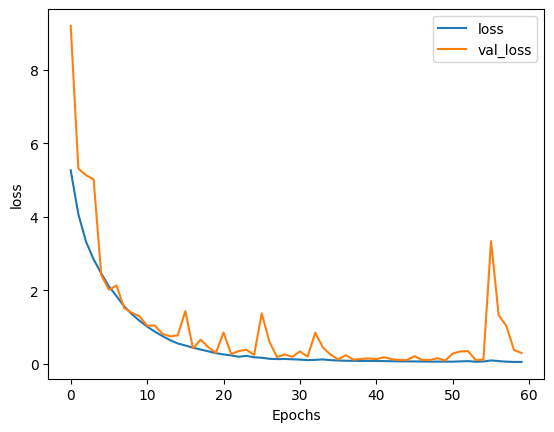

In [ ]:
plot_metrics(EfficientNet_model_history, 'loss')

In [ ]:
EfficientNet_model.evaluate(val_ds)

13/13 [==============================] - 3s 94ms/step - loss: 0.0797


0.07974376529455185

In [ ]:
# Building the Transfer Learning model using EfficientNetV2B0 with SGD
EfficientNet_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
EfficientNet_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = EfficientNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
EfficientNet_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
EfficientNet_model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
EfficientNet_model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_14 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 1280)              5919312   
 nal)                                                            
                                                                 
 batch_normalization_10 (Ba  (None, 1280)              5120      
 tchNormalization)                                               
                                                                 
 dense_18 (Dense)            (None, 256)               327936    
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_19 (Dense)            (None, 64)                1644

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  patience = 10,
                                                  restore_best_weights = True,
                                                  min_delta=0.01)

EfficientNet_model_history = EfficientNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 37s 229ms/step - loss: 6.4855 - val_loss: 7.3683
Epoch 2/100
51/51 [==============================] - 10s 167ms/step - loss: 6.2623 - val_loss: 6.5892
Epoch 3/100
51/51 [==============================] - 11s 196ms/step - loss: 6.1435 - val_loss: 6.2753
Epoch 4/100
51/51 [==============================] - 11s 201ms/step - loss: 6.0710 - val_loss: 6.1430
Epoch 5/100
51/51 [==============================] - 10s 189ms/step - loss: 5.9962 - val_loss: 6.0590
Epoch 6/100
51/51 [==============================] - 10s 172ms/step - loss: 5.9328 - val_loss: 5.9925
Epoch 7/100
51/51 [==============================] - 11s 180ms/step - loss: 5.8921 - val_loss: 5.9427
Epoch 8/100
51/51 [==============================] - 11s 199ms/step - loss: 5.8550 - val_loss: 5.9024
Epoch 9/100
51/51 [==============================] - 11s 195ms/step - loss: 5.8089 - val_loss: 5.8731
Epoch 10/100
51/51 [==============================] - 11s 194ms/step - loss: 5.756

In [ ]:
EfficientNet_model.evaluate(val_ds)

In [ ]:
# Building the Transfer Learning model using ResNet50
ResNet_base_model = tf.keras.applications.ResNet50(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
ResNet_base_model.trainable = True

# Create a new model on top of the ResNet50 base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = ResNet_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
ResNet_model = tf.keras.Model(inputs, outputs)

# Compile the model
ResNet_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Summary of the model
ResNet_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 batch_normalization_2 (Bat  (None, 2048)              8192      
 chNormalization)                                                
                                                                 
 dense_6 (Dense)             (None, 256)               524544    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 64)                16448     
                                                           

In [ ]:
ResNet_model_history = ResNet_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 48s 286ms/step - loss: 5.4538 - val_loss: 46822.5781
Epoch 2/100
51/51 [==============================] - 12s 227ms/step - loss: 4.5104 - val_loss: 110.0379
Epoch 3/100
51/51 [==============================] - 13s 229ms/step - loss: 3.9772 - val_loss: 7.1926
Epoch 4/100
51/51 [==============================] - 12s 224ms/step - loss: 3.6013 - val_loss: 39.7228
Epoch 5/100
51/51 [==============================] - 12s 222ms/step - loss: 3.2441 - val_loss: 307.8413
Epoch 6/100
51/51 [==============================] - 12s 221ms/step - loss: 2.9389 - val_loss: 4.4350
Epoch 7/100
51/51 [==============================] - 12s 225ms/step - loss: 2.7110 - val_loss: 9.8093
Epoch 8/100
51/51 [==============================] - 12s 227ms/step - loss: 2.4400 - val_loss: 8.0137
Epoch 9/100
51/51 [==============================] - 12s 223ms/step - loss: 2.2379 - val_loss: 7.2121
Epoch 10/100
51/51 [==============================] - 12s 224ms/step - lo

In [ ]:
ResNet_model.evaluate(val_ds)

13/13 [==============================] - 2s 109ms/step - loss: 0.3723


0.3723219931125641

In [ ]:
VGG_base_model = tf.keras.applications.VGG16(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
VGG_base_model.trainable = True

# Create a new model on top of the VGG16 base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = VGG_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
VGG_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
VGG_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
VGG_model.summary()

58889256/58889256 [==============================] - 1s 0us/step
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 batch_normalization_3 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dense_9 (Dense)             (None, 256)               131328    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_10 (Dense)            (None, 64)                16448

In [ ]:
VGG_model_history = VGG_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 40s 394ms/step - loss: 4.2437 - val_loss: 10.4043
Epoch 2/100
51/51 [==============================] - 13s 248ms/step - loss: 3.3966 - val_loss: 7.6539
Epoch 3/100
51/51 [==============================] - 14s 250ms/step - loss: 2.9682 - val_loss: 6.1445
Epoch 4/100
51/51 [==============================] - 14s 253ms/step - loss: 2.6280 - val_loss: 3.0077
Epoch 5/100
51/51 [==============================] - 15s 277ms/step - loss: 2.3639 - val_loss: 2.4761
Epoch 6/100
51/51 [==============================] - 14s 253ms/step - loss: 2.1503 - val_loss: 2.2245
Epoch 7/100
51/51 [==============================] - 17s 289ms/step - loss: 1.9823 - val_loss: 5.0620
Epoch 8/100
51/51 [==============================] - 13s 246ms/step - loss: 1.8313 - val_loss: 3.0791
Epoch 9/100
51/51 [==============================] - 13s 247ms/step - loss: 1.6981 - val_loss: 1.7752
Epoch 10/100
51/51 [==============================] - 13s 247ms/step - loss: 1.58

In [ ]:
VGG_model.evaluate(val_ds)

13/13 [==============================] - 2s 82ms/step - loss: 0.5446


0.5445966124534607

In [ ]:
Xception_base_model = tf.keras.applications.Xception(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
Xception_base_model.trainable = True

# Create a new model on top of the VGG16 base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = Xception_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
Xception_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
Xception_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
Xception_model.summary()

83683744/83683744 [==============================] - 1s 0us/step
Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 xception (Functional)       (None, 2048)              20861480  
                                                                 
 batch_normalization_8 (Bat  (None, 2048)              8192      
 chNormalization)                                                
                                                                 
 dense_12 (Dense)            (None, 256)               524544    
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 64)                16448

In [ ]:
Xception_model_history = Xception_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
51/51 [==============================] - 59s 537ms/step - loss: 3.6457 - val_loss: 2.7791
Epoch 2/100
51/51 [==============================] - 18s 320ms/step - loss: 2.1725 - val_loss: 2.4232
Epoch 3/100
51/51 [==============================] - 16s 288ms/step - loss: 1.7131 - val_loss: 2.2771
Epoch 4/100
51/51 [==============================] - 16s 291ms/step - loss: 1.4443 - val_loss: 2.0029
Epoch 5/100
51/51 [==============================] - 16s 280ms/step - loss: 1.2655 - val_loss: 8.3345
Epoch 6/100
51/51 [==============================] - 15s 274ms/step - loss: 1.1288 - val_loss: 1.6893
Epoch 7/100
51/51 [==============================] - 15s 274ms/step - loss: 0.9479 - val_loss: 1.9194
Epoch 8/100
51/51 [==============================] - 15s 281ms/step - loss: 0.8213 - val_loss: 1.2505
Epoch 9/100
51/51 [==============================] - 15s 277ms/step - loss: 0.7294 - val_loss: 1.1553
Epoch 10/100
51/51 [==============================] - 19s 358ms/step - loss: 0.674

In [ ]:
Xception_model.evaluate(val_ds)

13/13 [==============================] - 2s 78ms/step - loss: 0.2841


0.28406476974487305

## Prediction

In [ ]:
EfficientNet_model.save('EfficientNet_logloss_0.04.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
test = pd.read_csv('/content/drive/MyDrive/Контур/test.csv')
test['new_id'] = test.id.str.split('.').str.get(0)
image_list = os.listdir("/content/drive/MyDrive/Контур/images/test/")
data_image = pd.DataFrame(image_list, columns = ['name_ext'])
data_image['name'] = data_image.name_ext.str.split('.').str.get(0)
test = test.merge(data_image, how='left', left_on = 'new_id', right_on='name')

In [ ]:
pred_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Контур/images/test/",
  labels=None,
  seed = 512,
  image_size = (224, 224),
  batch_size = 16, shuffle=False)

Found 506 files belonging to 1 classes.


In [ ]:
filenames = pred_ds.file_paths
file_names = []

# Iterate through all image files in the specified directory
for file in filenames:
    label = str(file).split('/')[-1]  # Extract the label from the file path
    file_names.append(label)

In [ ]:
Inception_base_model = tf.keras.applications.InceptionV3(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    pooling = 'max'
)
Inception_base_model.trainable = True

# Create a new model on top of the EfficientNet base
inputs = tf.keras.Input(shape = (224, 224, 3))
x = Inception_base_model(inputs, training = False)
x = BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001)(x)
x = Dense(256,
          kernel_regularizer = regularizers.l2(0.01),
          activity_regularizer = regularizers.l1(0.01),
          bias_regularizer = regularizers.l1(0.01),
          activation = 'relu')(x)
x = Dropout(rate = .4, seed = 512)(x)
x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)
Inception_model = tf.keras.Model(inputs, outputs)

# Compile the Transfer Learning model
Inception_model.compile(
    optimizer = tf.keras.optimizers.Adamax(learning_rate = .001),
    loss = tf.keras.losses.BinaryCrossentropy()
)

# Build the Transfer Learning model so we can see a summary
Inception_model.summary()

87910968/87910968 [==============================] - 1s 0us/step
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 2048)              21802784  
                                                                 
 batch_normalization_98 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dense_9 (Dense)             (None, 256)               524544    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_10 (Dense)            (None, 64)                16448

In [ ]:
# model_inc.layers[0].trainable = False

In [ ]:
Inception_model_history = Inception_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100,
    verbose = 1,
    callbacks = [early_stopping]
)

Epoch 1/100
67/67 [==============================] - 585s 8s/step - loss: 5.5758 - val_loss: 29.8252
Epoch 2/100
67/67 [==============================] - 563s 8s/step - loss: 4.6286 - val_loss: 5630.6943
Epoch 3/100
67/67 [==============================] - 594s 9s/step - loss: 3.9996 - val_loss: 5.6235
Epoch 4/100
67/67 [==============================] - 563s 8s/step - loss: 3.5332 - val_loss: 4.4579
Epoch 5/100
67/67 [==============================] - 563s 8s/step - loss: 3.1749 - val_loss: 5.2034
Epoch 6/100
67/67 [==============================] - 564s 8s/step - loss: 2.8650 - val_loss: 4.1029
Epoch 7/100
67/67 [==============================] - 562s 8s/step - loss: 2.5695 - val_loss: 3.0741
Epoch 8/100
67/67 [==============================] - 565s 8s/step - loss: 2.2602 - val_loss: 2.3835
Epoch 9/100
67/67 [==============================] - 553s 8s/step - loss: 2.0329 - val_loss: 3.7346
Epoch 10/100
67/67 [==============================] - 549s 8s/step - loss: 1.7938 - val_loss: 1.

KeyboardInterrupt: 

In [ ]:
predictions = EfficientNet_model.predict(pred_ds)
predictions = predictions[:, 0]
pred_df = pd.DataFrame(list(zip(file_names, predictions)), columns = ['Name', 'target'])

32/32 [==============================] - 18s 451ms/step


In [ ]:
res = test.merge(pred_df, left_on='name_ext', right_on = 'Name', how='left')
res = res[['id', 'target']]
res = res[res.target.isna()==False]
res.target = res.target.apply(lambda x: 1-x)
res

,id,target
0,Qt1fGUB0Vz.jpeg,0.003308
1,j4Rhioq7R3.jpeg,0.069088
2,rD0hgFHJUZ.jpeg,0.003228
3,aY5z1EJsJ6.jpeg,0.999493
4,qZ3IoxD2TE.jpeg,0.004745
...,...,...
502,Qrme6EUmL1,0.998563
503,4369Dl8wfs.jpeg,0.004745
504,BrNEvRNpPu.jpeg,0.002802
506,DuwXCNmeMx.webp,0.534056


In [ ]:
res.to_csv('predictions.csv', index=False)

In [ ]:
EfficientNet_model.save('EfficientNet_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
EfficientNet_model.save('EfficientNet_model.keras')

ViT

In [ ]:
%pip install -U -q evaluate
%pip install -q transformers
%pip install -q datasets>=2.14.5
%pip install -q accelerate>=0.27
%pip install -q mlflow 2>/dev/null

In [ ]:
# Importing necessary libraries and modules
import warnings  # Import the 'warnings' module for handling warnings
warnings.filterwarnings("ignore")  # Ignore warnings during execution

import gc  # Import the 'gc' module for garbage collection
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import itertools  # Import 'itertools' for iterators and looping
from collections import Counter  # Import 'Counter' for counting elements
import matplotlib.pyplot as plt  # Import Matplotlib for data visualization
from sklearn.metrics import (  # Import various metrics from scikit-learn
    accuracy_score,  # For calculating accuracy
    roc_auc_score,  # For ROC AUC score
    confusion_matrix,  # For confusion matrix
    classification_report,  # For classification report
    f1_score  # For F1 score
)

# Import custom modules and classes
from imblearn.over_sampling import RandomOverSampler # import RandomOverSampler
import accelerate # Import the 'accelerate' module
import evaluate  # Import the 'evaluate' module
from datasets import Dataset, Image, ClassLabel  # Import custom 'Dataset', 'ClassLabel', and 'Image' classes
from transformers import (  # Import various modules from the Transformers library
    TrainingArguments,  # For training arguments
    Trainer,  # For model training
    ViTImageProcessor,  # For processing image data with ViT models
    ViTForImageClassification,  # ViT model for image classification
    DefaultDataCollator  # For collating data in the default way
)
import torch  # Import PyTorch for deep learning
from torch.utils.data import DataLoader  # For creating data loaders
from torchvision.transforms import (  # Import image transformation functions
    CenterCrop,  # Center crop an image
    Compose,  # Compose multiple image transformations
    Normalize,  # Normalize image pixel values
    RandomRotation,  # Apply random rotation to images
    RandomResizedCrop,  # Crop and resize images randomly
    RandomHorizontalFlip,  # Apply random horizontal flip
    RandomAdjustSharpness,  # Adjust sharpness randomly
    Resize,  # Resize images
    ToTensor  # Convert images to PyTorch tensors
)

In [ ]:
# Import the necessary module from the Python Imaging Library (PIL).
from PIL import ImageFile

# Enable the option to load truncated images.
# This setting allows the PIL library to attempt loading images even if they are corrupted or incomplete.
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
# Import necessary libraries
image_dict = {}

# Define the list of file names
from pathlib import Path
from tqdm import tqdm
import os
# Initialize empty lists to store file names and labels
file_names = []
labels = []

# Iterate through all image files in the specified directory
for file in sorted((Path('/content/drive/MyDrive/Контур/images').glob('*/*/*.*'))):
    label = str(file).split('/')[-2]  # Extract the label from the file path
    labels.append(label)  # Add the label to the list
    file_names.append(str(file))  # Add the file path to the list

# Print the total number of file names and labels
print(len(file_names), len(labels))

# Create a pandas dataframe from the collected file names and labels
df = pd.DataFrame.from_dict({"image": file_names, "label": labels})
print(df.shape)

In [ ]:
# random oversampling of minority class
# 'y' contains the target variable (label) we want to predict
y = df[['label']]

# Drop the 'label' column from the DataFrame 'df' to separate features from the target variable
df = df.drop(['label'], axis=1)

# Create a RandomOverSampler object with a specified random seed (random_state=83)
ros = RandomOverSampler(random_state=83)

# Use the RandomOverSampler to resample the dataset by oversampling the minority class
# 'df' contains the feature data, and 'y_resampled' will contain the resampled target variable
df, y_resampled = ros.fit_resample(df, y)

# Delete the original 'y' variable to save memory as it's no longer needed
del y

# Add the resampled target variable 'y_resampled' as a new 'label' column in the DataFrame 'df'
df['label'] = y_resampled

# Delete the 'y_resampled' variable to save memory as it's no longer needed
del y_resampled

# Perform garbage collection to free up memory used by discarded variables
gc.collect()

print(df.shape)

In [ ]:
# Create a dataset from a Pandas DataFrame.
dataset = Dataset.from_pandas(df).cast_column("image", Image())

In [ ]:
# Create a list of unique labels by converting 'labels' to a set and then back to a list
labels_list = ['REAL', 'FAKE'] #list(set(labels))

# Initialize empty dictionaries to map labels to IDs and vice versa
label2id, id2label = dict(), dict()

# Iterate over the unique labels and assign each label an ID, and vice versa
for i, label in enumerate(labels_list):
    label2id[label] = i  # Map the label to its corresponding ID
    id2label[i] = label  # Map the ID to its corresponding label

# Print the resulting dictionaries for reference
print("Mapping of IDs to Labels:", id2label, '\n')
print("Mapping of Labels to IDs:", label2id)

In [ ]:
# Creating classlabels to match labels to IDs
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

# Mapping labels to IDs
def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)

# Casting label column to ClassLabel Object
dataset = dataset.cast_column('label', ClassLabels)

# Splitting the dataset into training and testing sets using an 90-10 split ratio.
dataset = dataset.train_test_split(test_size=0.1, shuffle=True, stratify_by_column="label")

# Extracting the training data from the split dataset.
train_data = dataset['train']

# Extracting the testing data from the split dataset.
test_data = dataset['test']

In [ ]:
# Define the pre-trained ViT model string
model_str = "dima806/ai_vs_real_image_detection" #'google/vit-base-patch16-224-in21k'

# Create a processor for ViT model input from the pre-trained model
processor = ViTImageProcessor.from_pretrained(model_str)

# Retrieve the image mean and standard deviation used for normalization
image_mean, image_std = processor.image_mean, processor.image_std

# Get the size (height) of the ViT model's input images
size = processor.size["height"]
print("Size: ", size)

# Define a normalization transformation for the input images
normalize = Normalize(mean=image_mean, std=image_std)

# Define a set of transformations for training data
_train_transforms = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        RandomRotation(90),               # Apply random rotation
        RandomAdjustSharpness(2),         # Adjust sharpness randomly
        ToTensor(),                       # Convert images to tensors
        normalize                         # Normalize images using mean and std
    ]
)

# Define a set of transformations for validation data
_val_transforms = Compose(
    [
        Resize((size, size)),             # Resize images to the ViT model's input size
        ToTensor(),                       # Convert images to tensors
        normalize                         # Normalize images using mean and std
    ]
)

# Define a function to apply training transformations to a batch of examples
def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

# Define a function to apply validation transformations to a batch of examples
def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

In [ ]:
# Set the transforms for the training data
train_data.set_transform(train_transforms)

# Set the transforms for the test/validation data
test_data.set_transform(val_transforms)

In [ ]:
# Define a 12 function that prepares batched data for model training.
def collate_fn(examples):
    # Stack the pixel values from individual examples into a single tensor.
    pixel_values = torch.stack([example["pixel_values"] for example in examples])

    # Convert the label strings in examples to corresponding numeric IDs using label2id dictionary.
    labels = torch.tensor([example['label'] for example in examples])

    # Return a dictionary containing the batched pixel values and labels.
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
# Create a ViTForImageClassification model from a pretrained checkpoint with a specified number of output labels.
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))

# Configure the mapping of class labels to their corresponding indices for later reference.
model.config.id2label = id2label
model.config.label2id = label2id

# Calculate and print the number of trainable parameters in millions for the model.
print(model.num_parameters(only_trainable=True) / 1e6)

In [ ]:
# Load the accuracy metric from a module named 'evaluate'
accuracy = evaluate.load("accuracy")

# Define a function 'compute_metrics' to calculate evaluation metrics
def compute_metrics(eval_pred):
    # Extract model predictions from the evaluation prediction object
    predictions = eval_pred.predictions

    # Extract true labels from the evaluation prediction object
    label_ids = eval_pred.label_ids

    # Calculate accuracy using the loaded accuracy metric
    # Convert model predictions to class labels by selecting the class with the highest probability (argmax)
    predicted_labels = predictions.argmax(axis=1)

    # Calculate accuracy score by comparing predicted labels to true labels
    acc_score = accuracy.compute(predictions=predicted_labels, references=label_ids)['accuracy']

    # Return the computed accuracy as a dictionary with the key "accuracy"
    return {
        "accuracy": acc_score
    }

In [ ]:
from sklearn.metrics import log_loss
# Define a function 'compute_metrics' to calculate evaluation metrics
def compute_metrics(eval_pred):
    # Extract model predictions from the evaluation prediction object
    predictions = eval_pred.predictions

    # Extract true labels from the evaluation prediction object
    label_ids = eval_pred.label_ids

    # Calculate accuracy using the loaded accuracy metric
    # Convert model predictions to class labels by selecting the class with the highest probability (argmax)
    # predicted_labels = predictions.argmax(axis=1)

    # Calculate accuracy score by comparing predicted labels to true labels
    log_loss_score = log_loss(label_ids, predictions)
    # acc_score = accuracy.compute(predictions=predicted_labels, references=label_ids)['accuracy']

    # Return the computed accuracy as a dictionary with the key "accuracy"
    return {
        "log_loss": log_loss_score
    }

In [ ]:
# Define the name of the evaluation metric to be used during training and evaluation.
metric_name = "log_loss"

# Define the name of the model, which will be used to create a directory for saving model checkpoints and outputs.
model_name = "ai_vs_real_image_detection"

# Define the number of training epochs for the model.
num_train_epochs = 100

# Create an instance of TrainingArguments to configure training settings.
args = TrainingArguments(
    # Specify the directory where model checkpoints and outputs will be saved.
    output_dir=model_name,

    # Specify the directory where training logs will be stored.
    logging_dir='./logs',

    # Define the evaluation strategy, which is performed at the end of each epoch.
    evaluation_strategy="epoch",

    # Set the learning rate for the optimizer.
    learning_rate=3e-6,

    # Define the batch size for training on each device.
    per_device_train_batch_size=64,

    # Define the batch size for evaluation on each device.
    per_device_eval_batch_size=32,

    # Specify the total number of training epochs.
    num_train_epochs=num_train_epochs,

    # Apply weight decay to prevent overfitting.
    weight_decay=0.02,

    # Set the number of warm-up steps for the learning rate scheduler.
    warmup_steps=50,

    # Disable the removal of unused columns from the dataset.
    remove_unused_columns=False,

    # Define the strategy for saving model checkpoints (per epoch in this case).
    save_strategy='epoch',

    # Load the best model at the end of training.
    load_best_model_at_end=True,

    # Limit the total number of saved checkpoints to save space.
    save_total_limit=1,

    # Specify that training progress should not be reported .
    report_to="none"  # log to none
)

In [ ]:
# Create a Trainer instance for fine-tuning a language model.

# - `model`: The pre-trained language model to be fine-tuned.
# - `args`: Configuration settings and hyperparameters for training.
# - `train_dataset`: The dataset used for training the model.
# - `eval_dataset`: The dataset used for evaluating the model during training.
# - `data_collator`: A function that defines how data batches are collated and processed.
# - `compute_metrics`: A function for computing custom evaluation metrics.
# - `tokenizer`: The tokenizer used for processing text data.

trainer = Trainer(
    model,
    args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    tokenizer=processor,
)

In [ ]:
# Evaluate the pre-training model's performance on a test dataset.
# This function calculates various metrics such as accuracy, loss, etc.,
# to assess how well the model is performing on unseen data.

trainer.evaluate()

{'eval_loss': 0.5916974544525146,
 'eval_accuracy': 0.664179104477612,
 'eval_runtime': 4.4765,
 'eval_samples_per_second': 29.934,
 'eval_steps_per_second': 1.117}

In [ ]:
# Start training the model using the trainer object.
trainer.train()

Epoch,Training Loss,Validation Loss,Log Loss,Runtime,Samples Per Second,Steps Per Second
1,No log,0.648252,5.102901,9.018400,14.858000,0.554000
2,No log,0.547156,3.960255,3.255400,41.163000,1.536000
3,No log,0.517934,2.830292,3.353900,39.953000,1.491000
4,No log,0.459845,2.003389,3.986500,33.614000,1.254000
5,No log,0.412871,1.887299,3.495300,38.338000,1.431000
6,No log,0.369308,1.461546,3.451700,38.822000,1.449000
7,No log,0.348648,1.460411,3.378400,39.663000,1.480000
8,No log,0.316424,1.155380,3.386200,39.573000,1.477000
9,No log,0.310997,1.454195,3.292100,40.703000,1.519000
10,No log,0.277304,1.018201,3.360800,39.871000,1.488000


Epoch,Training Loss,Validation Loss,Log Loss,Runtime,Samples Per Second,Steps Per Second
1,No log,0.648252,5.102901,9.018400,14.858000,0.554000
2,No log,0.547156,3.960255,3.255400,41.163000,1.536000
3,No log,0.517934,2.830292,3.353900,39.953000,1.491000
4,No log,0.459845,2.003389,3.986500,33.614000,1.254000
5,No log,0.412871,1.887299,3.495300,38.338000,1.431000
6,No log,0.369308,1.461546,3.451700,38.822000,1.449000
7,No log,0.348648,1.460411,3.378400,39.663000,1.480000
8,No log,0.316424,1.155380,3.386200,39.573000,1.477000
9,No log,0.310997,1.454195,3.292100,40.703000,1.519000
10,No log,0.277304,1.018201,3.360800,39.871000,1.488000


In [ ]:
# Use the trained 'trainer' to make predictions on the 'test_data'.
outputs = trainer.predict(test_data)

# Print the metrics obtained from the prediction outputs.
print(outputs.metrics)

{'test_loss': 0.346491277217865, 'test_accuracy': 0.917910447761194, 'test_runtime': 4.1008, 'test_samples_per_second': 32.676, 'test_steps_per_second': 1.219}
